In [8]:
import os
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import pandas as pd
import imageio
from typing import Callable
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize, DummyVecEnv
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results, ts2xy

# Create directories for logging and models
LOG_DIR = "./logs/"
N_ENVS = 8
os.makedirs(LOG_DIR, exist_ok=True)


def record_improved_gif(model_path, stats_path, output_filename="improved_walker.gif"):
    # 1. Recreate the environment exactly as it was during training
    # Note: render_mode must be 'rgb_array' for imageio to capture frames
    env = gym.make("BipedalWalker-v3", render_mode="rgb_array")
    env = DummyVecEnv([lambda: env])
    
    # 2. Load the normalization statistics (CRITICAL for improved models)
    env = VecNormalize.load(stats_path, env)
    
    # IMPORTANT: Turn off training and reward normalization for testing/rendering
    env.training = False 
    env.norm_reward = False
    
    # 3. Load the trained model
    model = PPO.load(model_path, env=env)
    
    frames = []
    obs = env.reset()
    
    print("Recording frames...")
    # Record for one full episode 1600 for easy and 2000 for hardcore
    for i in range(2000):
        action, _ = model.predict(obs, deterministic=True)
        obs, rewards, dones, info = env.step(action)
        
        # Grab the frame from the vectorized environment
        # BipedalWalker-v3 returns a list of images (one per sub-env)
        frame = env.env_method("render")[0]
        frames.append(frame)
        
        if dones[0]:
            print(f"Episode finished in {i} steps.")
            break
            
    # 4. Save as GIF
    print(f"Saving GIF to {output_filename}...")
    imageio.mimsave(output_filename, frames, fps=30)
    print("Done!")

def save_gif(model, env, filename="agent_run.gif", length=500):
    """
    Runs the agent in the environment and saves the render as a GIF.
    """
    images = []
    vec_env = model.get_env()
    obs = vec_env.reset()
    
    print(f"Recording GIF: {filename}...")
    for i in range(length):
        action, _ = model.predict(obs, deterministic=True)
        obs, rewards, dones, info = vec_env.step(action)
        
        # Capture the frame
        # Note: BipedalWalker returns an RGB array when render_mode='rgb_array'
        img = vec_env.env_method("render")[0] 
        images.append(img)
        
        if dones[0]:
            break

    imageio.mimsave(filename, images, fps=30)
    print(f"Saved {filename}")

def moving_average(values, window):
    """
    Smooths the data for cleaner plotting.
    """
    weights = np.repeat(1.0, window) / window
    return np.convolve(values, weights, 'valid')

def plot_results(log_folder, title="Learning Curve"):
    x, y = ts2xy(load_results(log_folder), 'timesteps')
    y = moving_average(y, window=50)
    x = x[len(x) - len(y):]
    return x, y

def get_data_from_monitor(log_dir, name_filter):
    data = []
    for file in os.listdir(log_dir):
        if file.endswith(".csv") and name_filter in file:
            df = pd.read_csv(os.path.join(log_dir, file), skiprows=1)
            data.append(df)
    if not data: return None
    df_concat = pd.concat(data)
    # Sort by time
    df_concat = df_concat.sort_values(by='t')
    
    # Calculate cumulative timesteps
    df_concat['cumsum_l'] = df_concat['l'].cumsum()
    
    # Smooth rewards
    rewards = df_concat['r'].rolling(window=50).mean()
    return df_concat['cumsum_l'], rewards

# Test environment setup
env_test = gym.make("BipedalWalker-v3", render_mode="rgb_array")
print("Environment Observation Space:", env_test.observation_space)
print("Environment Action Space:", env_test.action_space)
env_test.close()

Environment Observation Space: Box([-3.1415927 -5.        -5.        -5.        -3.1415927 -5.
 -3.1415927 -5.        -0.        -3.1415927 -5.        -3.1415927
 -5.        -0.        -1.        -1.        -1.        -1.
 -1.        -1.        -1.        -1.        -1.        -1.       ], [3.1415927 5.        5.        5.        3.1415927 5.        3.1415927
 5.        5.        3.1415927 5.        3.1415927 5.        5.
 1.        1.        1.        1.        1.        1.        1.
 1.        1.        1.       ], (24,), float32)
Environment Action Space: Box(-1.0, 1.0, (4,), float32)


Training Baseline Model...
Eval num_timesteps=1250, episode_reward=-91.86 +/- 0.20
Episode length: 126.20 +/- 16.12
New best mean reward!
Eval num_timesteps=2500, episode_reward=-85.31 +/- 40.82
Episode length: 447.80 +/- 576.24
New best mean reward!
Eval num_timesteps=3750, episode_reward=-84.41 +/- 40.50
Episode length: 417.00 +/- 591.64
New best mean reward!
Eval num_timesteps=5000, episode_reward=-98.82 +/- 6.77
Episode length: 120.60 +/- 24.92
Eval num_timesteps=6250, episode_reward=-84.41 +/- 36.92
Episode length: 435.60 +/- 582.37
New best mean reward!
Eval num_timesteps=7500, episode_reward=-105.05 +/- 7.05
Episode length: 194.40 +/- 55.09
Eval num_timesteps=8750, episode_reward=-112.15 +/- 0.41
Episode length: 147.60 +/- 13.29
Eval num_timesteps=10000, episode_reward=-49.91 +/- 51.04
Episode length: 1066.40 +/- 657.28
New best mean reward!
Eval num_timesteps=11250, episode_reward=-111.50 +/- 0.15
Episode length: 64.40 +/- 0.80
Eval num_timesteps=12500, episode_reward=-112.59 +

d:\Users\draar\AppData\Local\Programs\Python\Python311\Lib\site-packages\imageio\plugins\pillow.py:409: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


Saved baseline_agent.gif


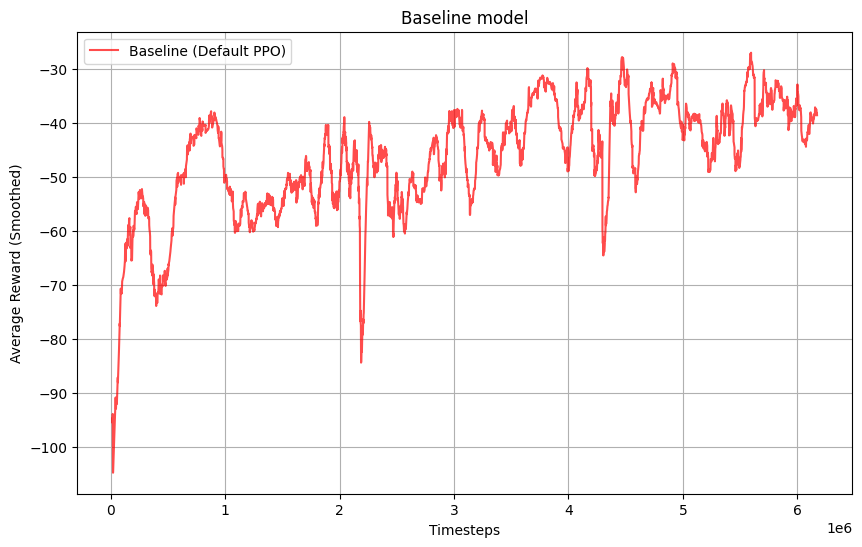

In [4]:
# 1. Setup the Baseline Environment (No Normalization, Default Rewards)
baseline_env = gym.make("BipedalWalker-v3", hardcore=True, render_mode="rgb_array")
baseline_env = Monitor(baseline_env, LOG_DIR + "baseline") # Wrap for logging
baseline_env = DummyVecEnv([lambda: baseline_env]) # Vectorize for SB3

eval_callback = EvalCallback(
    baseline_env,
    best_model_save_path=LOG_DIR + "best_model_hardcore_baseline",
    log_path=LOG_DIR + "results",
    eval_freq=max(10000 // N_ENVS, 1), # Adjust frequency for parallel envs
    deterministic=True,
    render=False
)

# 2. Define the Baseline Model
baseline_model = PPO(
    "MlpPolicy", 
    baseline_env, 
    verbose=0,
    seed=42
)

# 3. Train Baseline (Keep low for testing code, increase to 300k+ for real results)
# SUGGESTED FOR ASSIGNMENT: 100_000 for quick checks, 500_000+ to solve
BASELINE_STEPS = 1_000_000 
print("Training Baseline Model...")
baseline_model.learn(total_timesteps=BASELINE_STEPS, callback=eval_callback)
baseline_model.save(LOG_DIR + "baseline_model")
print("Baseline Training Complete.")

# 4. Save Baseline GIF
save_gif(baseline_model, baseline_env, filename="baseline_agent.gif")

plt.figure(figsize=(10, 6))

# Plot Baseline
bx, by = get_data_from_monitor(LOG_DIR, "baseline")
plt.plot(bx, by, label="Baseline (Default PPO)", color='red', alpha=0.7)

plt.xlabel("Timesteps")
plt.ylabel("Average Reward (Smoothed)")
plt.title("Baseline model")
plt.legend()
plt.grid(True)
plt.savefig("Basline_agent.png")
plt.show()

Training BipedalWalkerHardcore-v3...
Eval num_timesteps=50000, episode_reward=-99.41 +/- 1.10
Episode length: 65.20 +/- 7.76
New best mean reward!
Eval num_timesteps=100000, episode_reward=-125.05 +/- 23.62
Episode length: 1043.00 +/- 786.20
Eval num_timesteps=150000, episode_reward=-135.41 +/- 25.52
Episode length: 1197.80 +/- 668.36
Eval num_timesteps=200000, episode_reward=-126.79 +/- 30.96
Episode length: 1432.00 +/- 726.11
Eval num_timesteps=250000, episode_reward=-110.12 +/- 11.96
Episode length: 1487.40 +/- 686.84
Eval num_timesteps=300000, episode_reward=-135.95 +/- 41.13
Episode length: 1175.40 +/- 712.41
Eval num_timesteps=350000, episode_reward=-139.82 +/- 24.59
Episode length: 1768.00 +/- 464.00
Eval num_timesteps=400000, episode_reward=-137.80 +/- 33.62
Episode length: 2000.00 +/- 0.00
Eval num_timesteps=450000, episode_reward=-122.07 +/- 17.08
Episode length: 1646.00 +/- 708.00
Eval num_timesteps=500000, episode_reward=-131.28 +/- 27.02
Episode length: 896.40 +/- 660.99
E

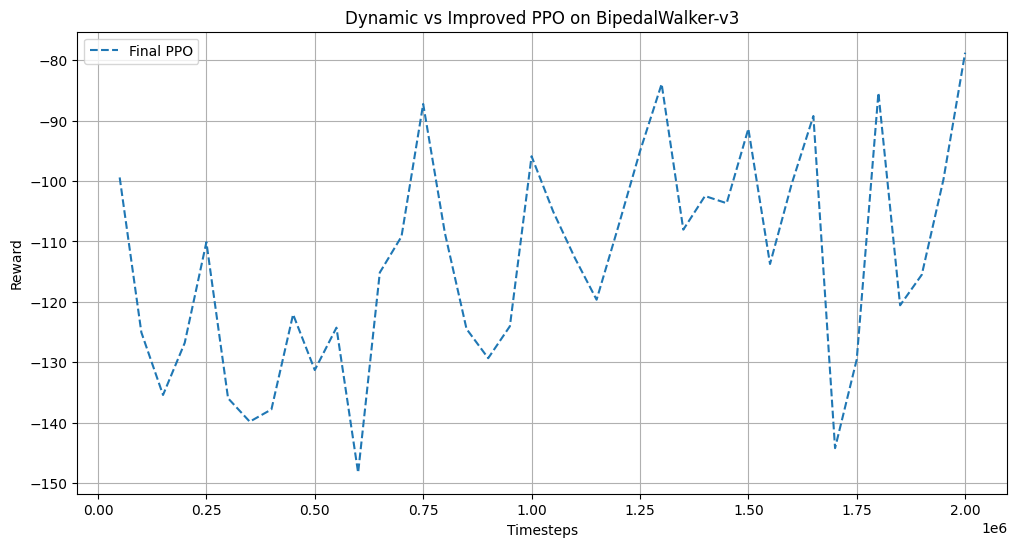

In [ ]:
# 1. CONSTANTS
LOG_DIR = "./logs_hardcore/"
# Hardcore mode needs significantly more steps (5M - 10M recommended)
DYNAMIC_STEPS = 2_000_000  
N_ENVS = 8 

# 2. LEARNING RATE SCHEDULE
def linear_schedule(initial_value: float, min_lr: float = 1e-5) -> Callable[[float], float]:
    def func(progress_remaining: float) -> float:
        return max(progress_remaining * initial_value, min_lr)
    return func

# 3. ENVIRONMENT SETUP
# Note the "Hardcore" addition
ENV_ID = "BipedalWalkerHardcore-v3"

env_dynamic = make_vec_env(ENV_ID, n_envs=N_ENVS)
env_dynamic = VecNormalize(
    env_dynamic, 
    norm_obs=True, 
    norm_reward=True, 
    clip_obs=10.,
    gamma=0.99
)

# 4. CALLBACKS
eval_env = make_vec_env(ENV_ID, n_envs=1)
eval_env = VecNormalize(eval_env, norm_obs=True, norm_reward=False, clip_obs=10., training=False)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=LOG_DIR + "best_model",
    log_path=LOG_DIR + "results",
    eval_freq=max(50000 // N_ENVS, 1), 
    deterministic=True,
    render=False
)

# 5. MODEL CONFIGURATION (Tuned for Hardcore)
dynamic_model = PPO(
    "MlpPolicy",
    env_dynamic,
    learning_rate=linear_schedule(3e-4, min_lr=3e-5),
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.00,
    use_sde=True,
    sde_sample_freq=4,
    max_grad_norm=0.5,
    verbose=0,
    seed=42,
    clip_range_vf=0.2,
    policy_kwargs=dict(
        log_std_init=-1,
        ortho_init=True,
        activation_fn=nn.Tanh,
        net_arch=dict(pi=[300, 300, 300], vf=[400, 300, 200])
    )
)

print(f"Training {ENV_ID}...")
dynamic_model.learn(total_timesteps=DYNAMIC_STEPS, callback=eval_callback)

# Save
dynamic_model.save(LOG_DIR + "hardcore_model")
env_dynamic.save(LOG_DIR + "vec_normalize_hardcore.pkl")
print("Hardcore Training Complete.")

eval_data = np.load(LOG_DIR + "results/evaluations.npz")
eval_timesteps = eval_data["timesteps"]
eval_results = eval_data["results"]

eval_mean = np.mean(eval_results, axis=1)
eval_std = np.std(eval_results, axis=1)
plt.figure(figsize=(12, 6))

# Evaluation curve
plt.plot(eval_timesteps, eval_mean, label="Final PPO", linestyle="--")
# plt.fill_between(
#     eval_timesteps,
#     eval_mean - eval_std,
#     eval_mean + eval_std,
#     alpha=0.2,
#     label="Evaluation ± Std"
# )

plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.title("Dynamic vs Improved PPO on BipedalWalker-v3")
plt.legend()
plt.grid(True)

plt.savefig("all_curves_combined.png")
plt.show()

Recording episode...
Saving GIF to walker_performance.gif...


d:\Users\draar\AppData\Local\Programs\Python\Python311\Lib\site-packages\imageio\plugins\pillow.py:409: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


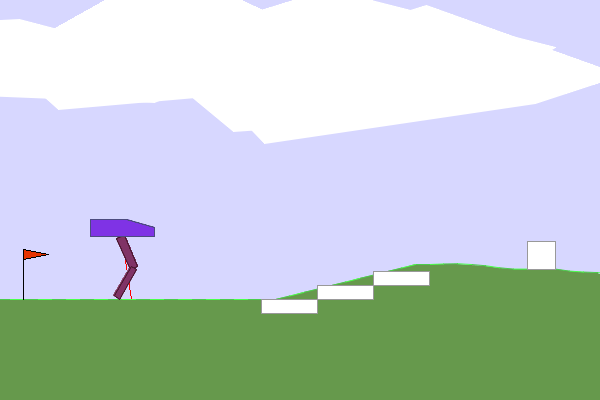

In [ ]:
LOG_DIR = "./logs_hardcore/"
ENV_ID = "BipedalWalkerHardcore-v3"
BEST_MODEL_PATH = LOG_DIR + "best_model/best_model.zip"
STATS_PATH = LOG_DIR + "vec_normalize_hardcore.pkl"
GIF_PATH = "walker_performance.gif"
from IPython.display import Image, display
def generate_and_show_gif():
    # 2. Create a fresh evaluation environment
    # render_mode="rgb_array" is required to capture frames
    eval_env = make_vec_env(
        ENV_ID,
        n_envs=1,
        env_kwargs={"render_mode": "rgb_array"}
    )
    
    # 3. Load normalization statistics
    # This is the most common reason for 'flopping' walkers if missed!
    eval_env = VecNormalize.load(STATS_PATH, eval_env)
    eval_env.training = False # Do not update stats during viz
    eval_env.norm_reward = False # Not needed for prediction
    
    # 4. Load the trained model
    model = PPO.load(BEST_MODEL_PATH)
    
    images = []
    obs = eval_env.reset()
    
    print("Recording episode...")
    # Record one full episode (usually ~1000-1600 steps max)
    for i in range(1600):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, info = eval_env.step(action)
        
        # Capture the frame
        # We use get_original_env() to bypass the VecNormalize wrapper for rendering
        img = eval_env.env_method("render")[0]
        images.append(img)
        
        if done:
            break

    # 5. Save the GIF
    print(f"Saving GIF to {GIF_PATH}...")
    imageio.mimsave(GIF_PATH, [np.array(img) for img in images], fps=30)
    
    # 6. Display in Jupyter
    display(Image(filename=GIF_PATH))

# Run the function
generate_and_show_gif()

In [38]:
import os
import gymnasium as gym
import torch.nn as nn
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize
from stable_baselines3.common.callbacks import EvalCallback, BaseCallback
from typing import Callable

# 1. CONSTANTS
LOG_DIR = "./logs_hardcore_final/"
DYNAMIC_STEPS = 1_000_000
N_ENVS = 8
os.makedirs(LOG_DIR, exist_ok=True)

# 2. RATE SCHEDULES
def linear_schedule(initial_value: float, min_lr: float = 1e-5) -> Callable[[float], float]:
    def func(progress_remaining: float) -> float:
        return max(progress_remaining * initial_value, min_lr)
    return func

class EntropyScheduleCallback(BaseCallback):
    def __init__(
        self,
        ent_coef_start: float,
        ent_coef_end: float,
        total_timesteps: int,
        verbose: int = 0,
    ):
        super().__init__(verbose)
        self.ent_coef_start = ent_coef_start
        self.ent_coef_end = ent_coef_end
        self.total_timesteps = total_timesteps

    def _on_step(self) -> bool:
        progress = self.num_timesteps / self.total_timesteps
        progress = min(progress, 1.0)

        new_ent_coef = self.ent_coef_start + progress * (
            self.ent_coef_end - self.ent_coef_start
        )
        self.model.ent_coef = float(new_ent_coef)
        return True

# 3. ENVIRONMENT SETUP (Vectorized)
# make_vec_env handles the creation of multiple processes automatically
env_curriculum = make_vec_env("BipedalWalker-v3", n_envs=N_ENVS)

# Normalize observations and rewards (Crucial for PPO/BipedalWalker)
env_curriculum = VecNormalize(
    env_curriculum, 
    norm_obs=True, 
    norm_reward=True, 
    clip_obs=10.,
    gamma=0.998
)

# 4. CALLBACKS
entropy_callback = EntropyScheduleCallback(
    ent_coef_start=0.001,
    ent_coef_end=0.0001,
    total_timesteps=DYNAMIC_STEPS
)

# Separate evaluation env to test true performance without exploration noise/normalization updates
eval_env = make_vec_env("BipedalWalker-v3", n_envs=1)
eval_env = VecNormalize(eval_env, norm_obs=True, norm_reward=False, clip_obs=10., training=False)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=LOG_DIR + "best_model_curriculum",
    log_path=LOG_DIR + "results_curriculum",
    eval_freq=max(20000 // N_ENVS, 1), # Adjust frequency for parallel envs
    deterministic=True,
    render=False
)

# 5. MODEL CONFIGURATION
hardcore_model = PPO(
    "MlpPolicy",
    env_curriculum,
    learning_rate=linear_schedule(3e-4, min_lr=1e-4),
    n_steps=2048,
    batch_size=1024,
    n_epochs=10,
    gamma=0.998,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    use_sde=True,
    sde_sample_freq=4,
    max_grad_norm=0.5,  
    verbose=0,
    seed=42,
    policy_kwargs=dict(
        log_std_init=-2,
        ortho_init=True,
        activation_fn=nn.Tanh,
        net_arch=dict(pi=[256, 256], vf=[256, 256]) 
    )
)

print("Training Dynamic Model with gSDE and Parallel Envs...")
# Note: total_timesteps is distributed across all envs
hardcore_model.learn(total_timesteps=DYNAMIC_STEPS, callback=[eval_callback, entropy_callback])

# Save final model and the normalization stats
hardcore_model.save(LOG_DIR + "curriculum_model")
env_curriculum.save(LOG_DIR + "vec_normalize_curriculum.pkl")
print("Training Complete.")

Training Dynamic Model with gSDE and Parallel Envs...
Eval num_timesteps=20000, episode_reward=-112.80 +/- 0.26
Episode length: 164.40 +/- 20.22
New best mean reward!
Eval num_timesteps=40000, episode_reward=-111.42 +/- 0.12
Episode length: 82.60 +/- 1.02
New best mean reward!
Eval num_timesteps=60000, episode_reward=-105.51 +/- 6.61
Episode length: 151.00 +/- 7.16
New best mean reward!
Eval num_timesteps=80000, episode_reward=-71.88 +/- 31.14
Episode length: 731.40 +/- 709.42
New best mean reward!
Eval num_timesteps=100000, episode_reward=-55.50 +/- 20.68
Episode length: 1307.40 +/- 585.20
New best mean reward!
Eval num_timesteps=120000, episode_reward=-48.74 +/- 4.70
Episode length: 1600.00 +/- 0.00
New best mean reward!
Eval num_timesteps=140000, episode_reward=-36.70 +/- 5.93
Episode length: 1600.00 +/- 0.00
New best mean reward!
Eval num_timesteps=160000, episode_reward=-88.35 +/- 16.20
Episode length: 1009.40 +/- 723.68
Eval num_timesteps=180000, episode_reward=-38.30 +/- 6.63
Ep

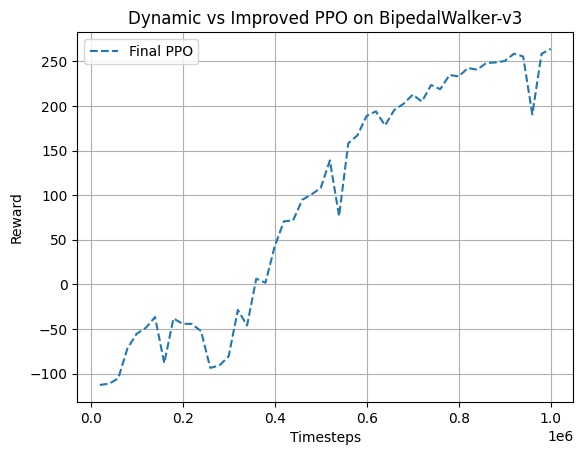

In [39]:
eval_data = np.load(LOG_DIR + "results_curriculum/evaluations.npz")
eval_timesteps = eval_data["timesteps"]
eval_results = eval_data["results"]

eval_mean = np.mean(eval_results, axis=1)
eval_std = np.std(eval_results, axis=1)

# Evaluation curve
plt.plot(eval_timesteps, eval_mean, label="Final PPO", linestyle="--")
# plt.fill_between(
#     eval_timesteps,
#     eval_mean - eval_std,
#     eval_mean + eval_std,
#     alpha=0.2,
#     label="Evaluation ± Std"
# )
plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.title("Dynamic vs Improved PPO on BipedalWalker-v3")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
record_improved_gif(
    model_path=LOG_DIR + "best_model_curriculum/best_model.zip", 
    stats_path=LOG_DIR + "vec_normalize_curriculum.pkl",
    output_filename="curriculum.gif"
)

Recording frames...
Episode finished in 1350 steps.
Saving GIF to curriculum.gif...


d:\Users\draar\AppData\Local\Programs\Python\Python311\Lib\site-packages\imageio\plugins\pillow.py:409: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


Done!


In [41]:
HARDCORE_STEPS = 10_000_000
hardcore_env = make_vec_env("BipedalWalkerHardcore-v3", n_envs=N_ENVS)
hardcore_env = VecNormalize.load(
    LOG_DIR + "vec_normalize_curriculum.pkl",
    hardcore_env
)
hardcore_env.training = True
hardcore_env.norm_reward = True
hardcore_eval_env = make_vec_env("BipedalWalkerHardcore-v3", n_envs=1)
hardcore_eval_env = VecNormalize(
    hardcore_eval_env,
    norm_obs=True,
    norm_reward=False,
    clip_obs=10.,
    training=False
)
hardcore_eval_callback = EvalCallback(
    hardcore_eval_env,
    best_model_save_path=LOG_DIR + "best_model",
    log_path=LOG_DIR + "results",
    eval_freq=max(60000 // N_ENVS, 1),
    deterministic=True,
    render=False
)
hardcore_entropy_callback = EntropyScheduleCallback(
    ent_coef_start=0.001,   
    ent_coef_end=0.0,      
    total_timesteps=HARDCORE_STEPS
)
hardcore_model = PPO.load(
    LOG_DIR + "curriculum_model",
    env=hardcore_env,
    device="auto"
)
hardcore_model.learning_rate = linear_schedule(1e-4, min_lr=5e-5)

print("Retraining on BipedalWalkerHardcore-v3...")

hardcore_model.learn(
    total_timesteps=HARDCORE_STEPS,
    callback=[hardcore_eval_callback, hardcore_entropy_callback],
    reset_num_timesteps=False  # CONTINUE TIMESTEP COUNT
)

# 5. SAVE FINAL HARDCORE MODEL
hardcore_model.save(LOG_DIR + "hardcore_model")
hardcore_env.save(LOG_DIR + "vec_normalize_hardcore.pkl")

print("Hardcore Training Complete.")

Retraining on BipedalWalkerHardcore-v3...
Eval num_timesteps=1075808, episode_reward=-100.21 +/- 29.47
Episode length: 320.00 +/- 268.21
New best mean reward!
Eval num_timesteps=1135808, episode_reward=-136.79 +/- 35.69
Episode length: 1108.80 +/- 807.29
Eval num_timesteps=1195808, episode_reward=-159.77 +/- 46.83
Episode length: 1204.20 +/- 578.49
Eval num_timesteps=1255808, episode_reward=-103.70 +/- 49.64
Episode length: 1312.00 +/- 794.63
Eval num_timesteps=1315808, episode_reward=-94.22 +/- 28.42
Episode length: 1598.20 +/- 657.10
New best mean reward!
Eval num_timesteps=1375808, episode_reward=-84.91 +/- 36.61
Episode length: 1668.00 +/- 664.00
New best mean reward!
Eval num_timesteps=1435808, episode_reward=-88.13 +/- 23.30
Episode length: 716.20 +/- 653.37
Eval num_timesteps=1495808, episode_reward=-63.12 +/- 20.40
Episode length: 907.00 +/- 583.00
New best mean reward!
Eval num_timesteps=1555808, episode_reward=-88.00 +/- 42.27
Episode length: 906.40 +/- 893.06
Eval num_timest

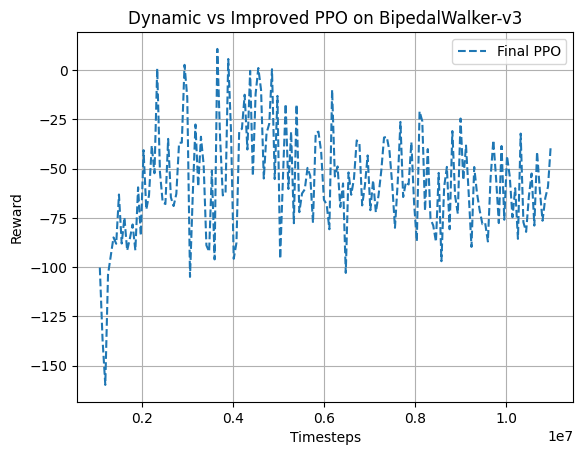

In [42]:
eval_data = np.load(LOG_DIR + "results/evaluations.npz")
eval_timesteps = eval_data["timesteps"]
eval_results = eval_data["results"]

eval_mean = np.mean(eval_results, axis=1)
eval_std = np.std(eval_results, axis=1)

# Evaluation curve
plt.plot(eval_timesteps, eval_mean, label="Final PPO", linestyle="--")
# plt.fill_between(
#     eval_timesteps,
#     eval_mean - eval_std,
#     eval_mean + eval_std,
#     alpha=0.2,
#     label="Evaluation ± Std"
# )
plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.title("Dynamic vs Improved PPO on BipedalWalker-v3")
plt.legend()
plt.grid(True)
plt.show()

In [47]:
def record_gif(model_path, stats_path, output_filename="improved_walker.gif"):
    # 1. Recreate the environment exactly as it was during training
    # Note: render_mode must be 'rgb_array' for imageio to capture frames
    env = gym.make("BipedalWalkerHardcore-v3", render_mode="rgb_array")
    env = DummyVecEnv([lambda: env])
    
    # 2. Load the normalization statistics (CRITICAL for improved models)
    env = VecNormalize.load(stats_path, env)
    
    # IMPORTANT: Turn off training and reward normalization for testing/rendering
    env.training = False 
    env.norm_reward = False
    
    # 3. Load the trained model
    model = PPO.load(model_path, env=env)
    
    frames = []
    obs = env.reset()
    
    print("Recording frames...")
    # Record for one full episode 1600 for easy and 2000 for hardcore
    for i in range(2000):
        action, _ = model.predict(obs, deterministic=True)
        obs, rewards, dones, info = env.step(action)
        
        # Grab the frame from the vectorized environment
        # BipedalWalker-v3 returns a list of images (one per sub-env)
        frame = env.env_method("render")[0]
        frames.append(frame)
        
        if dones[0]:
            print(f"Episode finished in {i} steps.")
            break
            
    # 4. Save as GIF
    print(f"Saving GIF to {output_filename}...")
    imageio.mimsave(output_filename, frames, fps=30)
    print("Done!")

record_gif(
    model_path=LOG_DIR + "hardcore_model.zip", 
    stats_path=LOG_DIR + "vec_normalize_hardcore.pkl",
    output_filename="hardcore.gif"
)

Recording frames...
Episode finished in 117 steps.
Saving GIF to hardcore.gif...


d:\Users\draar\AppData\Local\Programs\Python\Python311\Lib\site-packages\imageio\plugins\pillow.py:409: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


Done!


In [ ]:
HARDCORE_STEPS = 10_000_000
hardcore_env = make_vec_env("BipedalWalkerHardcore-v3", n_envs=N_ENVS)
hardcore_env = VecNormalize.load(
    LOG_DIR + "vec_normalize_curriculum.pkl",
    hardcore_env
)
hardcore_env.training = True
hardcore_env.norm_reward = True
hardcore_eval_env = make_vec_env("BipedalWalkerHardcore-v3", n_envs=1)
hardcore_eval_env = VecNormalize(
    hardcore_eval_env,
    norm_obs=True,
    norm_reward=False,
    clip_obs=10.,
    training=False
)
hardcore_eval_callback = EvalCallback(
    hardcore_eval_env,
    best_model_save_path=LOG_DIR + "best_model",
    log_path=LOG_DIR + "results",
    eval_freq=max(60000 // N_ENVS, 1),
    deterministic=True,
    render=False
)
hardcore_entropy_callback = EntropyScheduleCallback(
    ent_coef_start=0.001,   
    ent_coef_end=0.0,      
    total_timesteps=HARDCORE_STEPS
)
hardcore_model = PPO(
    "MlpPolicy",
    env_curriculum,
    learning_rate=linear_schedule(3e-4, min_lr=1e-4),
    n_steps=2048,
    batch_size=1024,
    n_epochs=10,
    gamma=0.998,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    use_sde=True,
    sde_sample_freq=4,
    max_grad_norm=0.5,  
    verbose=0,
    seed=42,
    policy_kwargs=dict(
        log_std_init=-2,
        ortho_init=True,
        activation_fn=nn.Tanh,
        net_arch=dict(pi=[256, 256], vf=[256, 256]) 
    )
)

print("Training on BipedalWalkerHardcore-v3...")

hardcore_model.learn(
    total_timesteps=HARDCORE_STEPS,
    callback=[hardcore_eval_callback],
)

# 5. SAVE FINAL HARDCORE MODEL
hardcore_model.save(LOG_DIR + "hardcore_model")
hardcore_env.save(LOG_DIR + "vec_normalize_hardcore.pkl")

print("Hardcore Training Complete.")

Retraining on BipedalWalkerHardcore-v3...
Eval num_timesteps=60000, episode_reward=-39.56 +/- 13.29
Episode length: 2000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=120000, episode_reward=-58.55 +/- 15.09
Episode length: 2000.00 +/- 0.00
Eval num_timesteps=180000, episode_reward=-87.58 +/- 39.78
Episode length: 2000.00 +/- 0.00
Eval num_timesteps=240000, episode_reward=-70.72 +/- 30.24
Episode length: 2000.00 +/- 0.00
Eval num_timesteps=300000, episode_reward=-113.32 +/- 33.72
Episode length: 1611.60 +/- 776.80
Eval num_timesteps=360000, episode_reward=-75.55 +/- 30.12
Episode length: 2000.00 +/- 0.00
Eval num_timesteps=420000, episode_reward=-82.50 +/- 4.53
Episode length: 2000.00 +/- 0.00
Eval num_timesteps=480000, episode_reward=-112.48 +/- 30.06
Episode length: 1703.40 +/- 593.20
Eval num_timesteps=540000, episode_reward=-87.02 +/- 33.27
Episode length: 1133.80 +/- 719.38
Eval num_timesteps=600000, episode_reward=-90.83 +/- 29.86
Episode length: 684.60 +/- 715.57
Eval num_